In [2]:
# Import basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load dataset
from sklearn.datasets import load_iris

In [4]:
iris = load_iris()

In [5]:
# Convert to DataFrame
df = pd.DataFrame(iris.data, columns=iris.feature_names)

In [6]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [7]:
# Rename columns
df.columns = ['sepal_length','sepal_width','petal_length','petal_width']

In [8]:
# Add species column
df['species'] = iris.target

In [9]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [10]:
# Map species names
df['species'] = df['species'].map({0:'setosa',1:'versicolor',2:'virginica'})

In [11]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [12]:
# Check shape
df.shape

(150, 5)

In [13]:
# Check info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [14]:
# Check null values
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [15]:
# Describe data
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


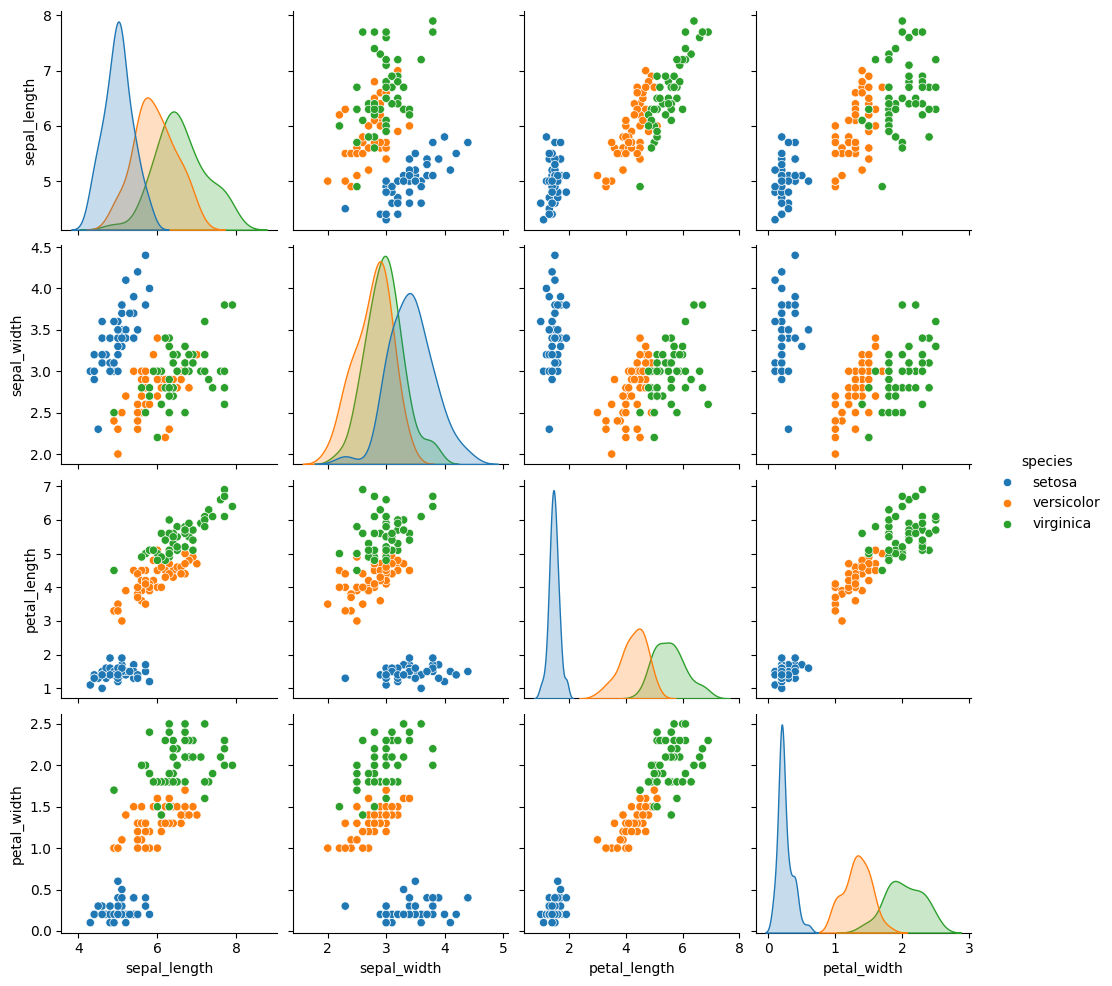

In [16]:
# Pairplot
sns.pairplot(df, hue='species')

In [17]:
# Heatmap
# sns.heatmap(df.corr(), annot=True)

In [18]:
# Features only
X = df[['sepal_length','sepal_width','petal_length','petal_width']]

In [19]:
X.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [20]:
# Scaling
from sklearn.preprocessing import StandardScaler

In [21]:
scaler = StandardScaler()

In [22]:
X_scaled = scaler.fit_transform(X)

In [23]:
X_scaled[:5]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

In [24]:
from sklearn.cluster import KMeans

In [25]:
# Elbow method
wcss = []

In [26]:
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

c:\Users\Infra\miniconda3\envs\sum25\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Infra\miniconda3\envs\sum25\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Infra\miniconda3\envs\sum25\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Infra\miniconda3\envs\sum25\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will c

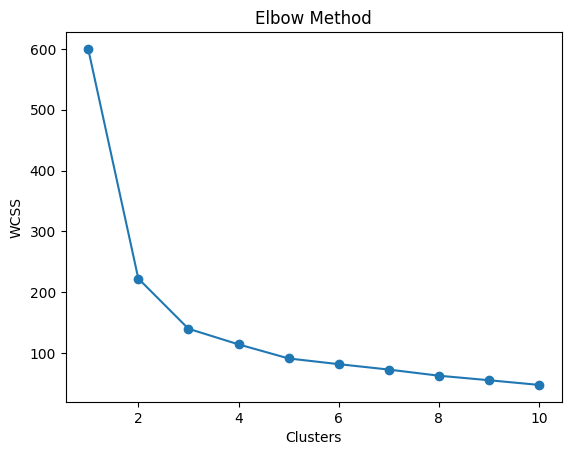

In [27]:
# Plot elbow
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [28]:
# Apply KMeans (k=3)
kmeans = KMeans(n_clusters=3, random_state=42)

In [29]:
y_kmeans = kmeans.fit_predict(X_scaled)

c:\Users\Infra\miniconda3\envs\sum25\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [30]:
df['cluster'] = y_kmeans

In [31]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,cluster
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


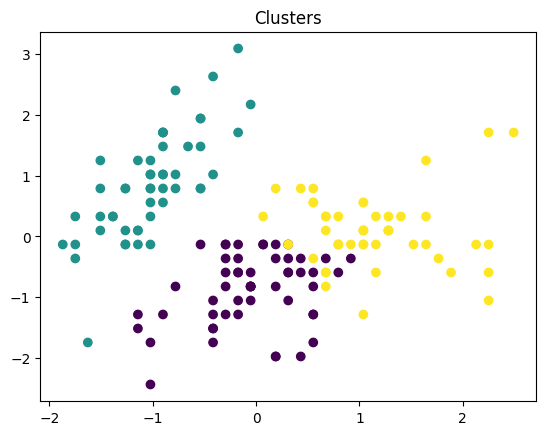

In [32]:
# Visualization
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y_kmeans)
plt.title("Clusters")
plt.show()

In [33]:
# Cluster centers
kmeans.cluster_centers_

array([[-0.05021989, -0.88337647,  0.34773781,  0.2815273 ],
       [-1.01457897,  0.85326268, -1.30498732, -1.25489349],
       [ 1.13597027,  0.08842168,  0.99615451,  1.01752612]])

In [34]:
# Take user input
sepal_length = float(input("Enter sepal_length: "))
sepal_width = float(input("Enter sepal_width: "))
petal_length = float(input("Enter petal_length: "))
petal_width = float(input("Enter petal_width: "))
input_data = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
input_data_scaled = scaler.transform(input_data)
prediction = kmeans.predict(input_data_scaled)
print("Predicted cluster:", prediction[0])



Predicted cluster: 2


c:\Users\Infra\miniconda3\envs\sum25\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [35]:
# Compare cluster vs species
pd.crosstab(df['cluster'], df['species'])

species,setosa,versicolor,virginica
cluster,,,
0,0,39,14
1,50,0,0
2,0,11,36


In [36]:
# Approximate mapping
cluster_map = {
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
}

In [37]:
print("Predicted Species:", cluster_map[prediction[0]])

Predicted Species: Virginica


In [38]:
# Save model (optional)
import pickle
pickle.dump(kmeans, open("kmeans_model.pkl","wb"))
pickle.dump(scaler, open("scaler.pkl","wb"))
print("Model saved successfully")



Model saved successfully


In [39]:
# Load model
model = pickle.load(open("kmeans_model.pkl","rb"))

In [40]:
print("Model loaded")

Model loaded


In [41]:
# confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
# Since KMeans is unsupervised, we will use the original species labels for evaluation
y_true = df['species']
y_pred = df['cluster'].map(cluster_map)
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))
print("\nClassification Report:")
print(classification_report(y_true, y_pred))


Confusion Matrix:
[[ 0  0  0  0  0  0]
 [ 0  0  0  0  0  0]
 [ 0  0  0  0  0  0]
 [ 0 50  0  0  0  0]
 [39  0 11  0  0  0]
 [14  0 36  0  0  0]]

Classification Report:
              precision    recall  f1-score   support

      Setosa       0.00      0.00      0.00       0.0
  Versicolor       0.00      0.00      0.00       0.0
   Virginica       0.00      0.00      0.00       0.0
      setosa       0.00      0.00      0.00      50.0
  versicolor       0.00      0.00      0.00      50.0
   virginica       0.00      0.00      0.00      50.0

    accuracy                           0.00     150.0
   macro avg       0.00      0.00      0.00     150.0
weighted avg       0.00      0.00      0.00     150.0



c:\Users\Infra\miniconda3\envs\sum25\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Infra\miniconda3\envs\sum25\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Infra\miniconda3\envs\sum25\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\Users\Infra\miniconda3\e

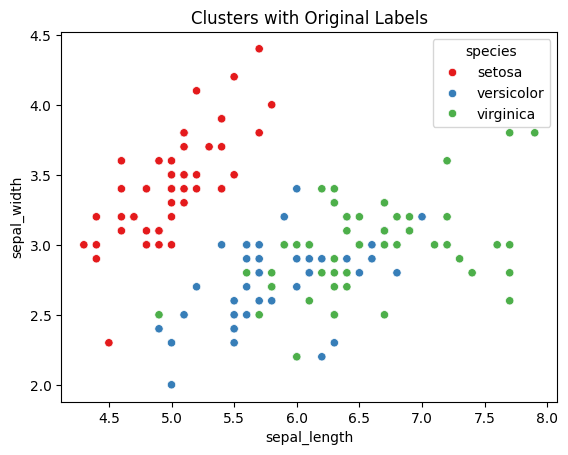

In [ ]:
#lab 2
# visualize clusters with original labels
sns.scatterplot(x='sepal_length', y='sepal_width', hue='species', data=df, palette='Set1')
plt.title("Clusters with Original Labels")
plt.show()


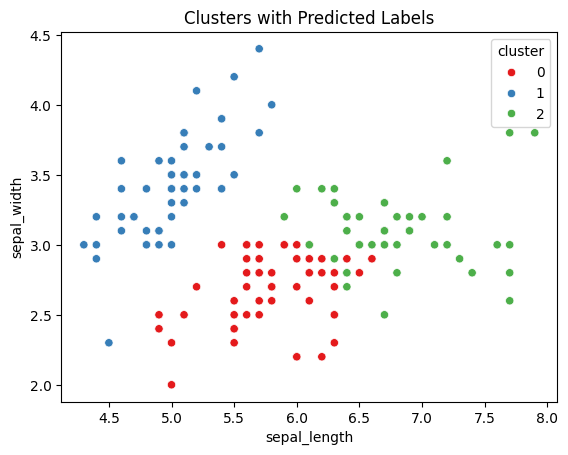

In [45]:
#visualize clusters with predicted labels
sns.scatterplot(x='sepal_length', y='sepal_width', hue='cluster', data=df, palette='Set1')
plt.title("Clusters with Predicted Labels")
plt.show()